/home/onyxia/work/Projet_pythonDS/src/donnees.py:8: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(nom_fichier_csv, sep=';', encoding='UTF-8')
/home/onyxia/work/Projet_pythonDS/src/donnees.py:8: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(nom_fichier_csv, sep=';', encoding='UTF-8')


nombre d'accidents :  163942
nombre de victimes :  367699
     dep     nb
100  975     13
102  977     57
104  986     59
103  978    187
90    90    319
..   ...    ...
94    94  14626
12    13  15493
92    92  16029
93    93  17979
75    75  29042

[107 rows x 2 columns]
['Blessé hospitalisé' 'Indemne' 'Blessé léger' 'Tué']


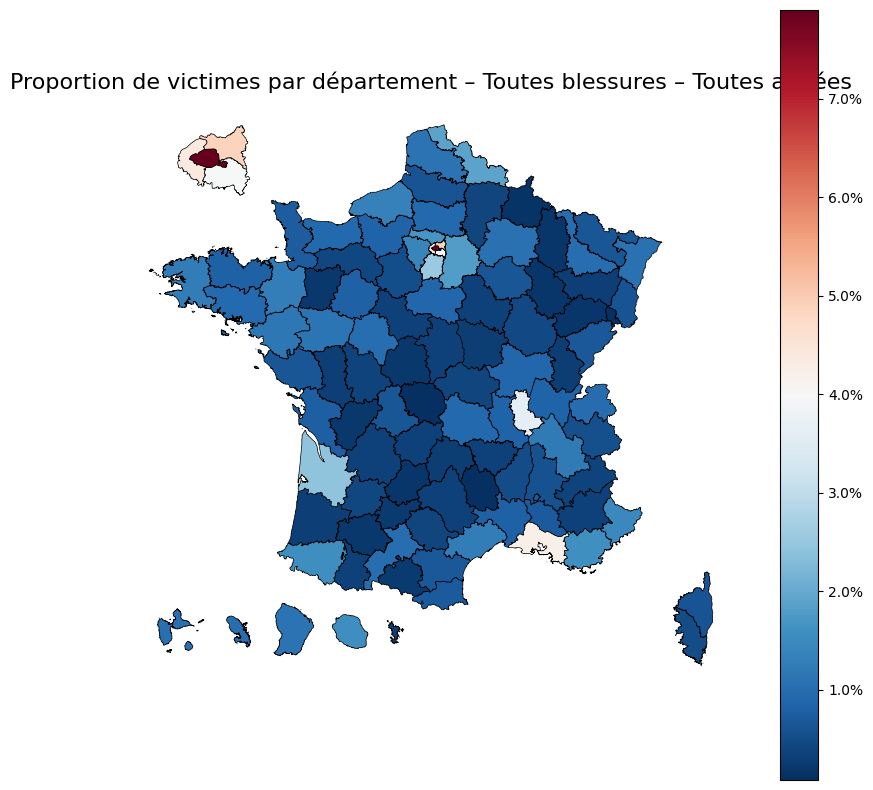

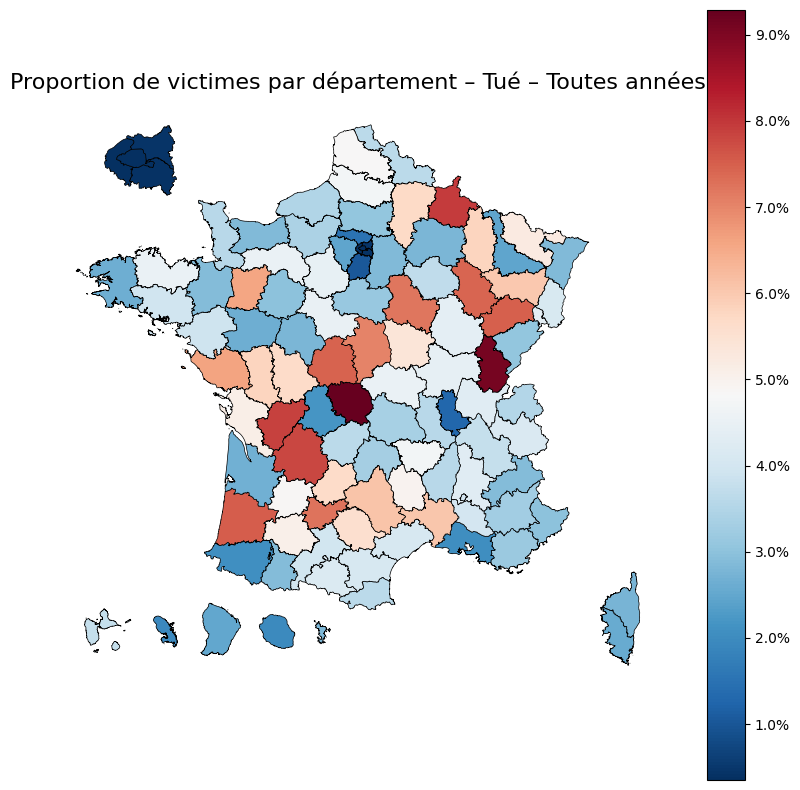

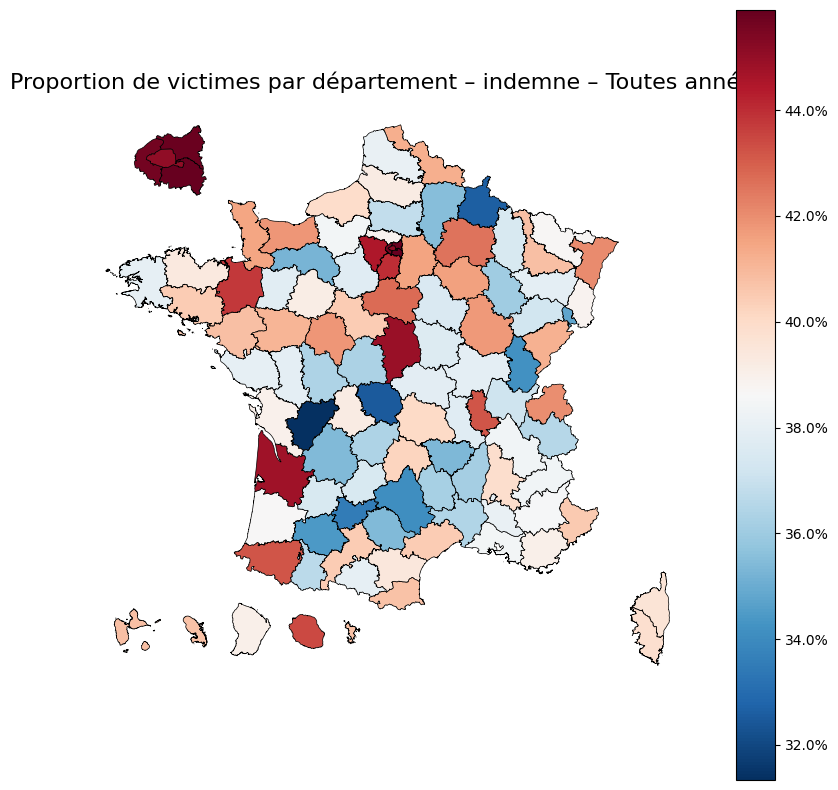

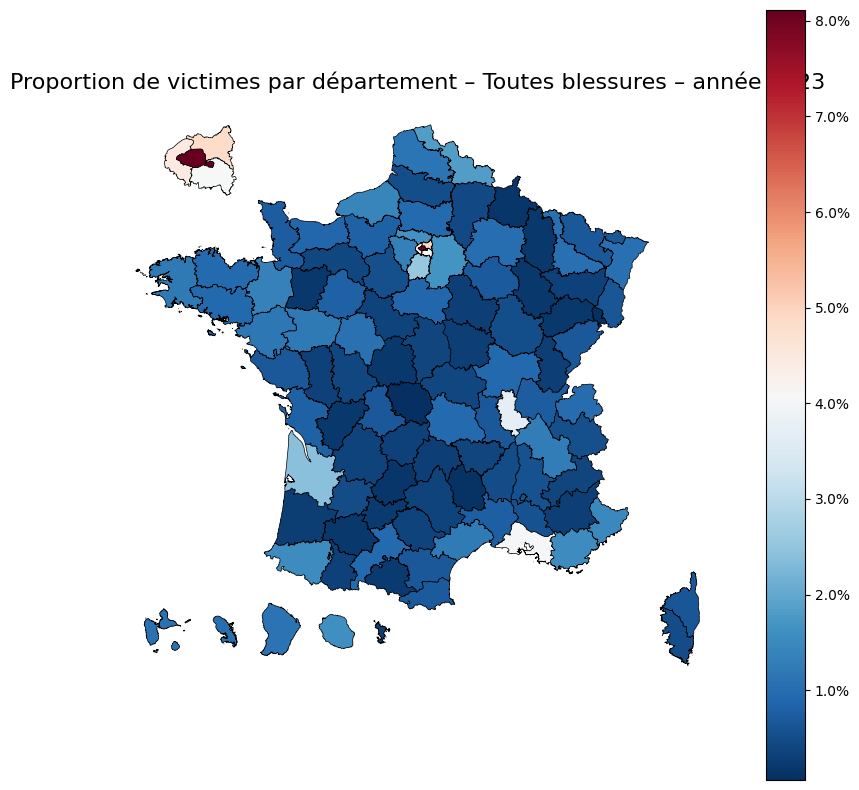

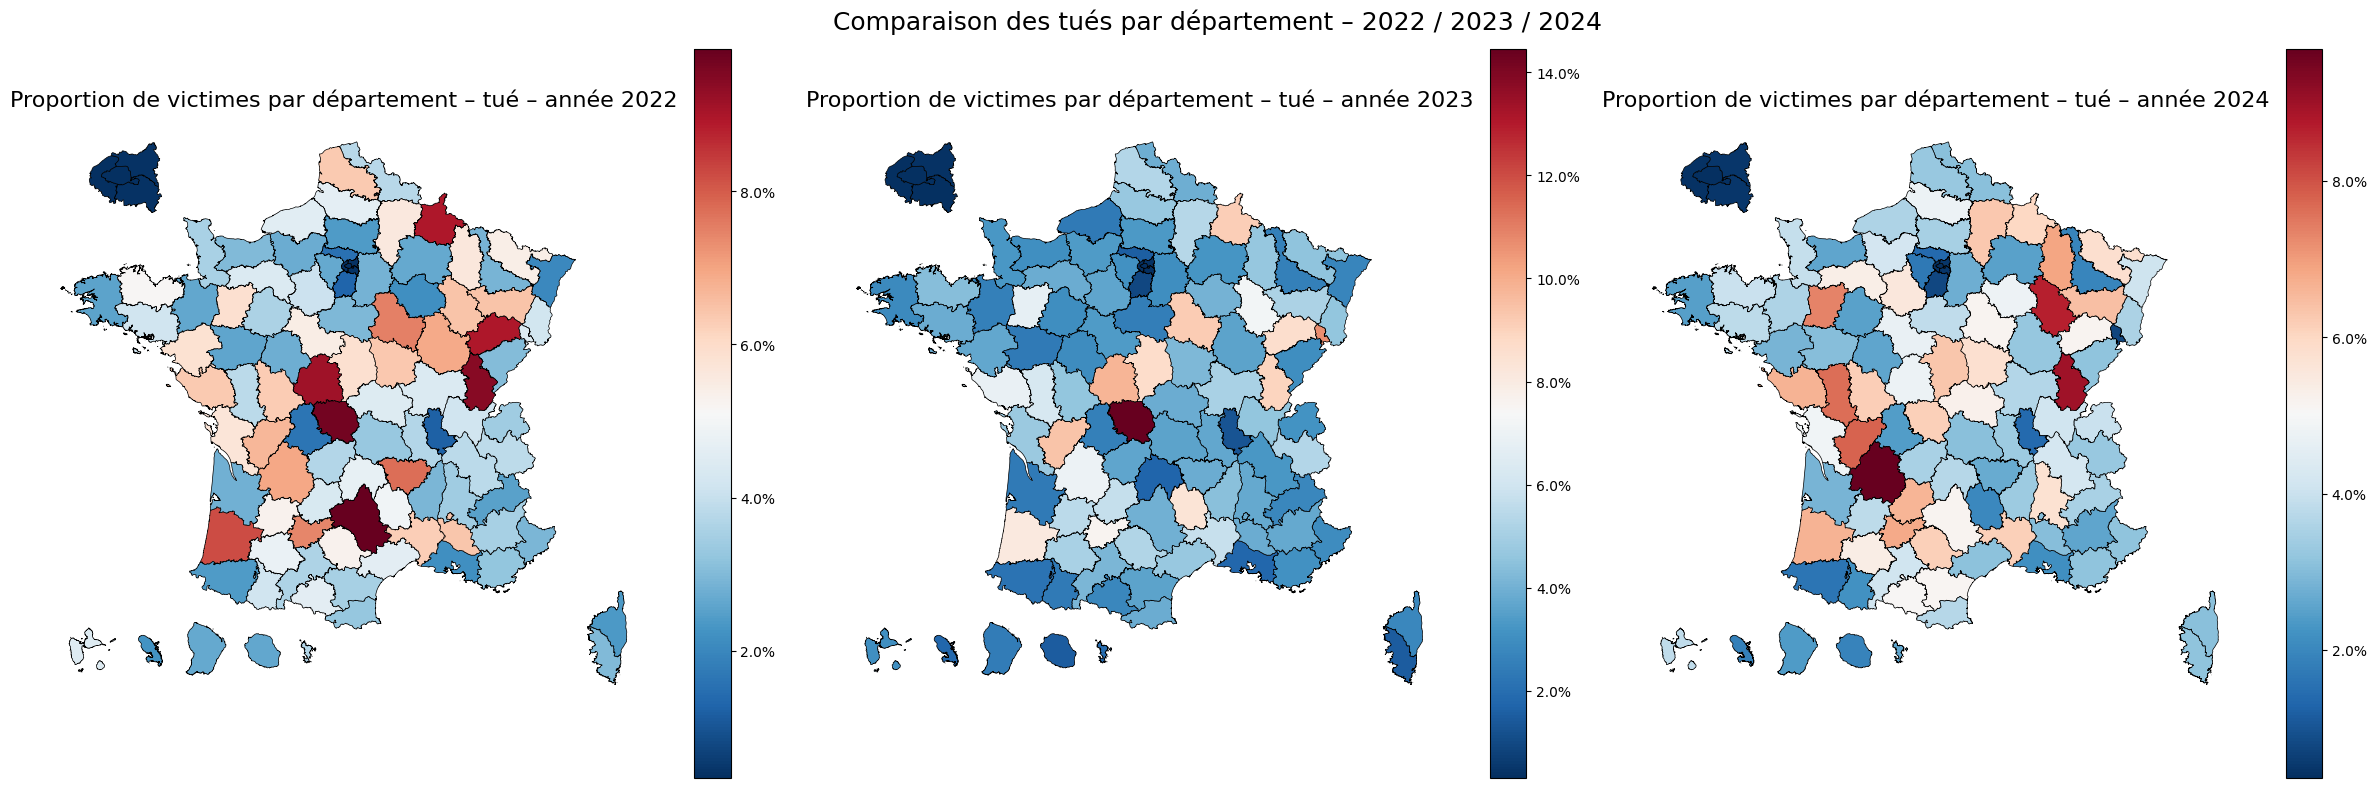

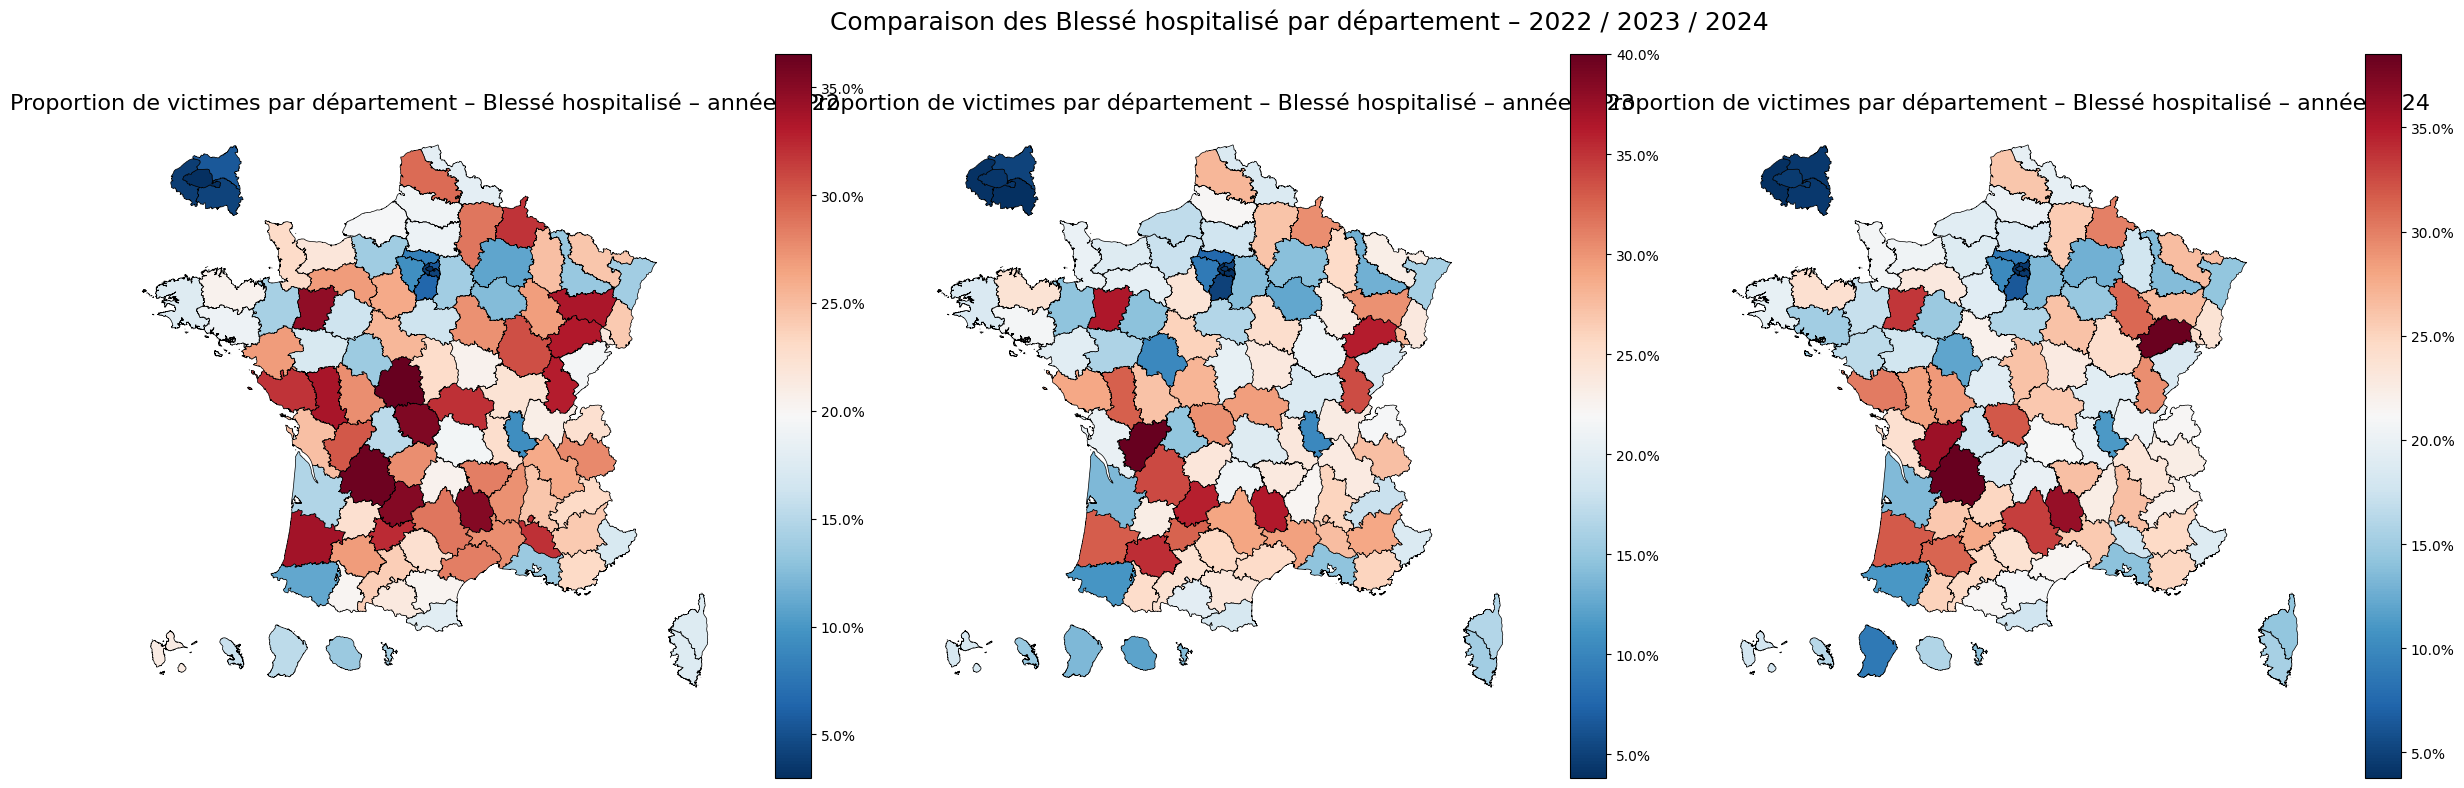

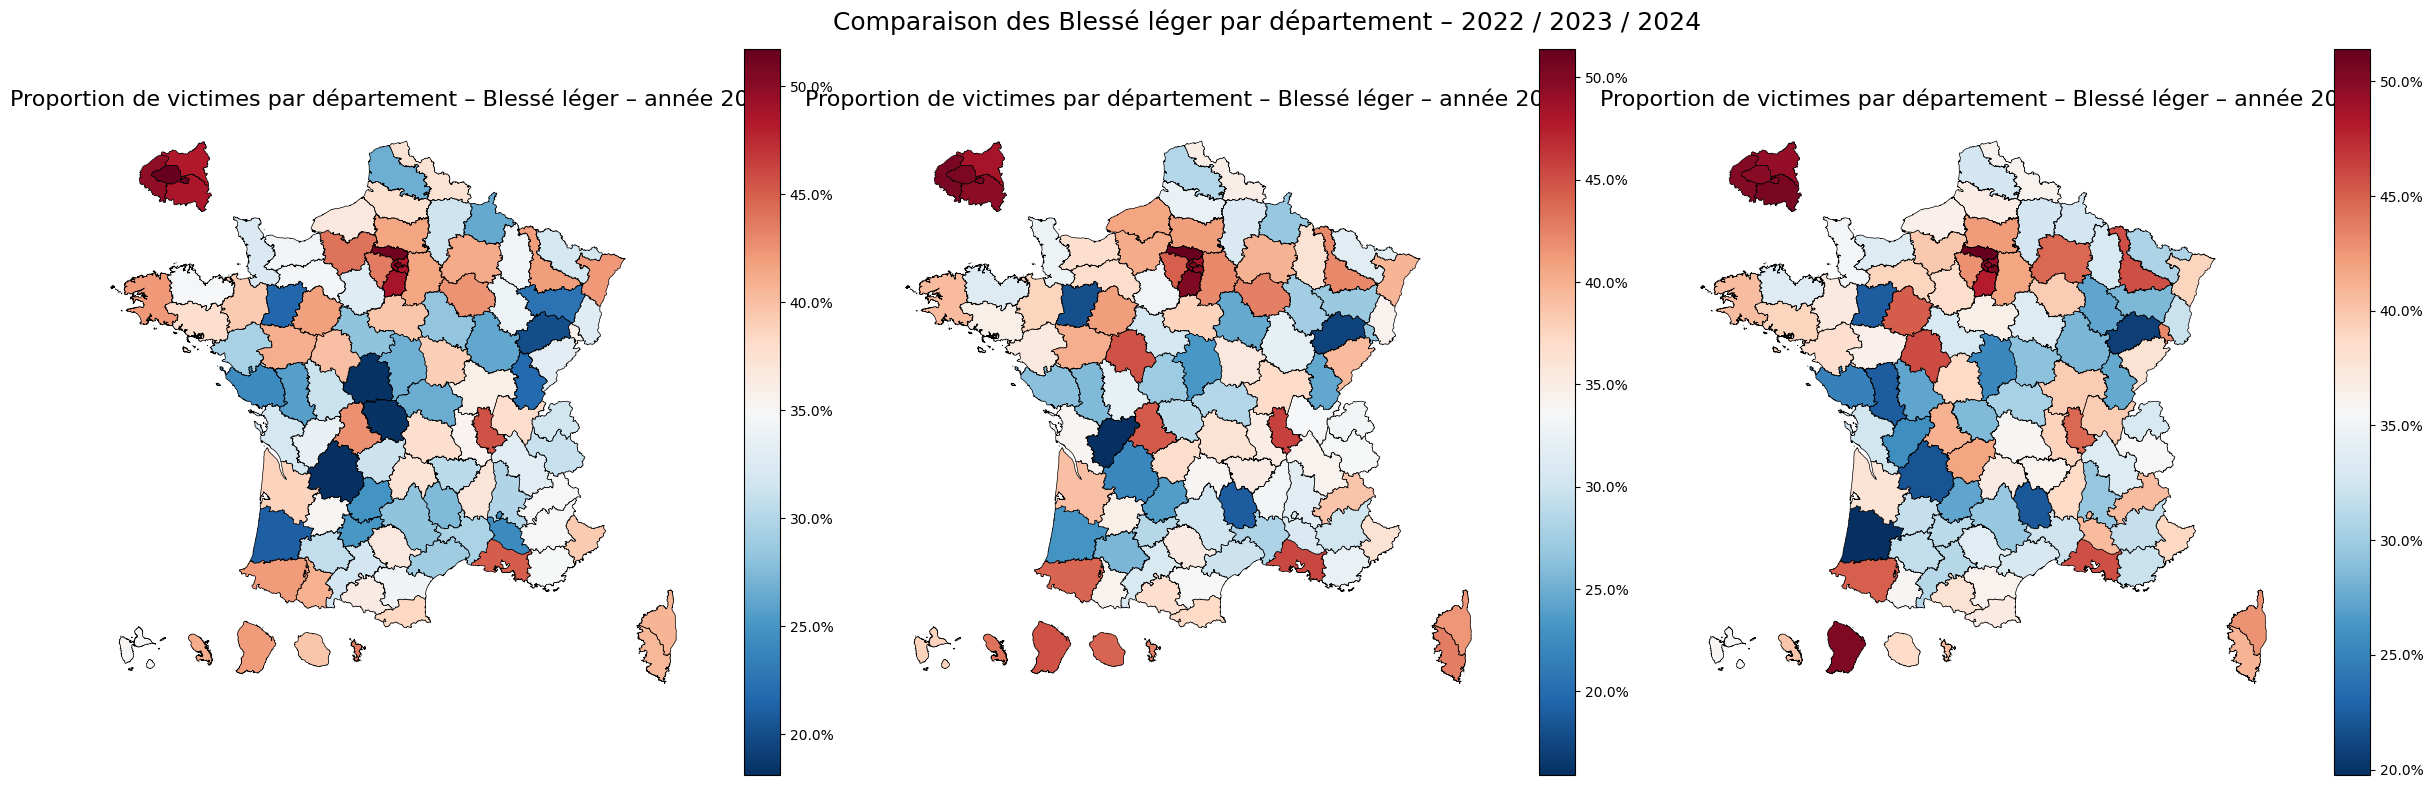

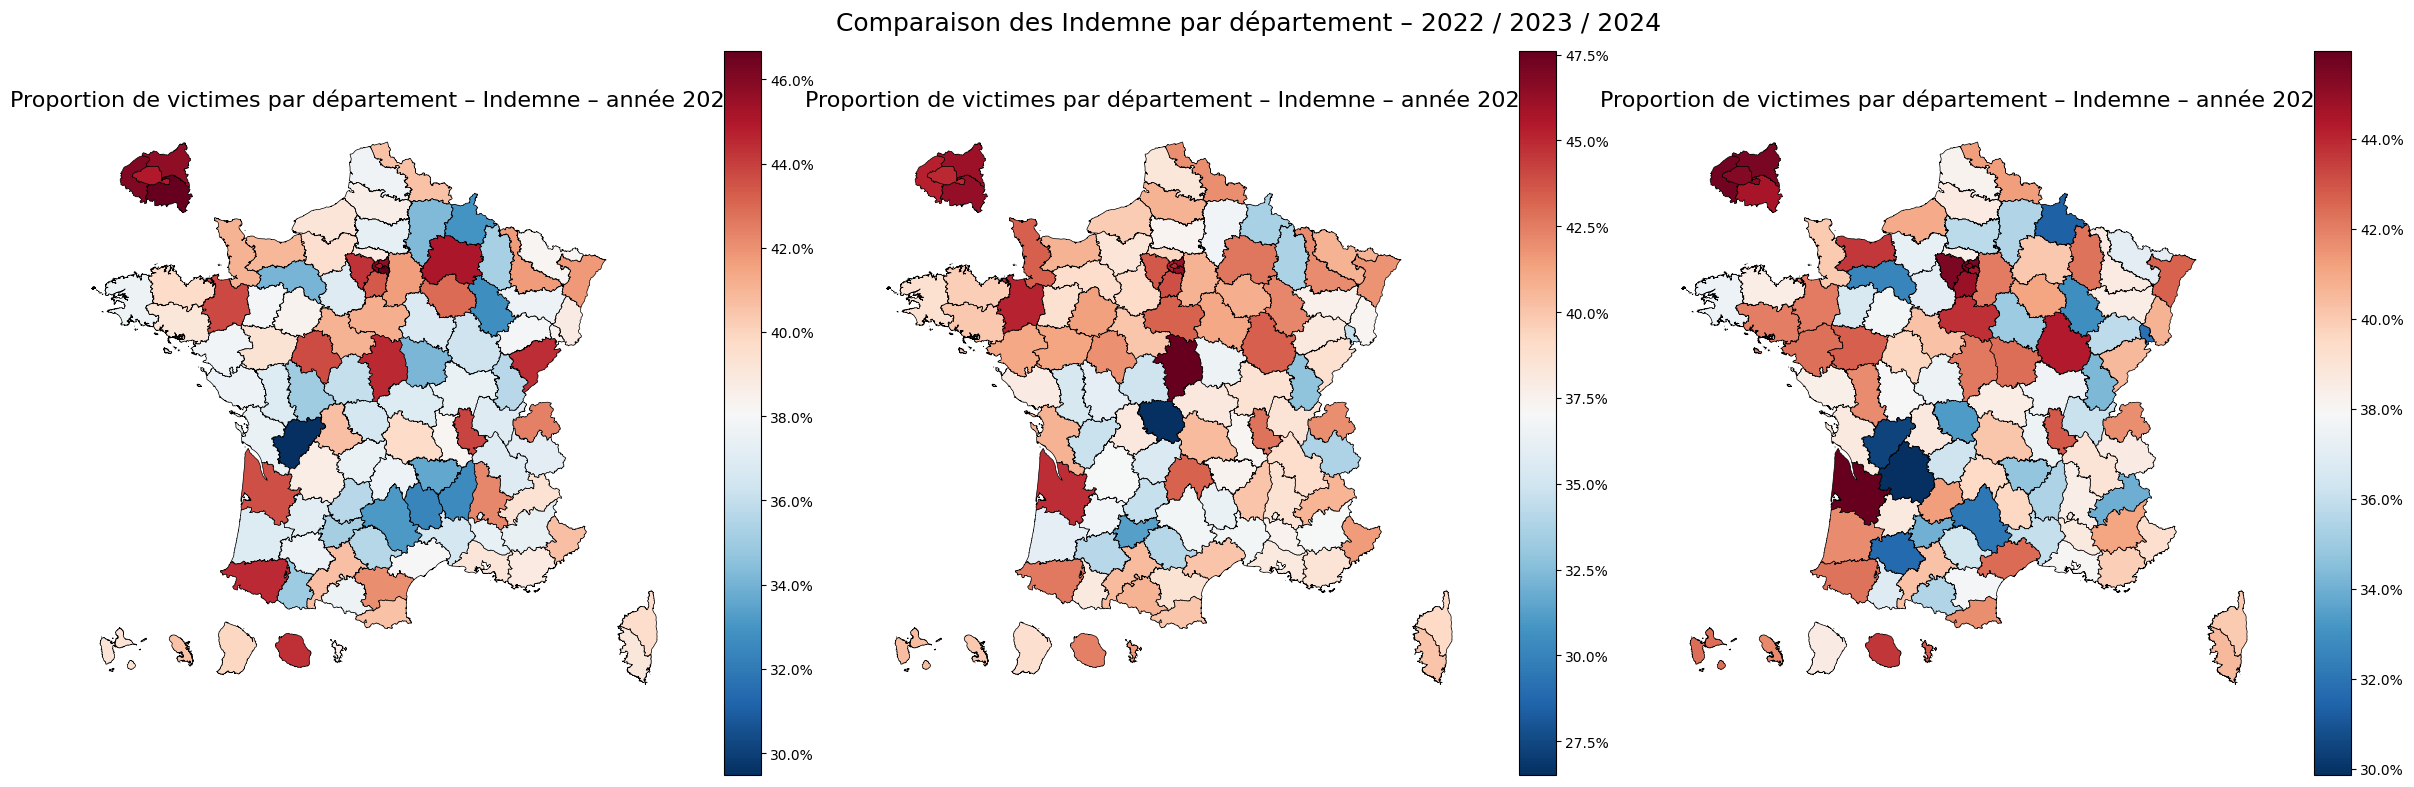

In [2]:
%run main.ipynb

# df_caract_recoder
# df_lieux_recoder
# df_vehicule_recoder
# df_usager_recoder
# df_final

# Modelisation :
- classification avec gravité en variables catégorielle : 1 = Indemne, 2 = Blessé léger, 3 = Blessé hospitalisé, 4 = Tué
- Random Forest 
- Facteurs clés : type de véhicule, ancienneté du véhicule, choc avant / arrière / latéral, âge, sexe, port de la ceinture / casque, alcoolémie, météo, luminosité, état de la chaussée, type de route (autoroute, nationale, départementale), zone (urbaine / rurale), département, zone accidentogène (a rajouter ?), heure, saison (a rajouter ?)
- A faire : one hot encoding, gérer les valeurs manquantes 

In [3]:
df_final["grav"].unique()

array(['Blessé hospitalisé', 'Indemne', 'Blessé léger', 'Tué'],
      dtype=object)

In [4]:
df_final.columns

Index(['Num_Acc', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'agg', 'int',
       'atm', 'col', 'lat', 'long', 'mois_num', 'catr', 'circ', 'nbv', 'vosp',
       'prof', 'plan', 'surf', 'infra', 'situ', 'vma', 'id_vehicule', 'catv',
       'obs', 'obsm', 'choc', 'manv', 'id_usager', 'catu', 'grav', 'sexe',
       'trajet', 'secu1', 'age', 'date', 'jour_semaine', 'hr'],
      dtype='object')

## I - Random Forest

In [5]:
import numpy as np
import random

np.random.seed(66)
random.seed(66)

In [6]:
grav_dict = {
    "Indemne":1,
    "Tué":4,
    "Blessé hospitalisé":3,
    "Blessé léger":2
}
df_final = recodage(df_final, {"grav": grav_dict})
df_final = df_final.dropna(subset=['grav'])

In [7]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 367699 entries, 0 to 377701
Data columns (total 40 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Num_Acc       367699 non-null  Int64         
 1   jour          367699 non-null  int64         
 2   mois          367699 non-null  object        
 3   an            367699 non-null  int64         
 4   hrmn          367699 non-null  object        
 5   lum           367699 non-null  object        
 6   dep           367699 non-null  object        
 7   agg           367699 non-null  object        
 8   int           367699 non-null  object        
 9   atm           367699 non-null  object        
 10  col           367699 non-null  object        
 11  lat           367699 non-null  object        
 12  long          367699 non-null  object        
 13  mois_num      367699 non-null  int64         
 14  catr          367699 non-null  object        
 15  circ          345149 n

In [8]:
y = df_final["grav"].astype(int).astype(str)
X = df_final[[
    "mois", "an", "lum", "dep", "agg", "int", "surf", "vma", "catv", "obs",
    "obsm", "choc", "sexe", "situ", "secu1", "age", "atm", "col", "catr",
    "prof", "plan", "manv", "catu", "jour_semaine", "hr"
]]
X["an"] = X["an"].astype(str)

/tmp/ipykernel_4821/2612545770.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["an"] = X["an"].astype(str)


### Vérification des valeurs manquantes - A FAIRE

In [9]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 367699 entries, 0 to 377701
Data columns (total 25 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   mois          367699 non-null  object
 1   an            367699 non-null  object
 2   lum           367699 non-null  object
 3   dep           367699 non-null  object
 4   agg           367699 non-null  object
 5   int           367699 non-null  object
 6   surf          367699 non-null  object
 7   vma           367699 non-null  int64 
 8   catv          367699 non-null  object
 9   obs           367699 non-null  object
 10  obsm          367699 non-null  object
 11  choc          367699 non-null  object
 12  sexe          367699 non-null  object
 13  situ          367699 non-null  object
 14  secu1         367699 non-null  object
 15  age           367699 non-null  Int64 
 16  atm           367699 non-null  object
 17  col           367699 non-null  object
 18  catr          367699 non-null

### Encodage des variables explicatives 

In [10]:
import pandas as pd

X_encoded = pd.get_dummies(X, drop_first=True)

# Train, test 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=66, stratify=y
)
# startify pour les classes déséquilibré 


In [11]:
X_train

,vma,age,mois_avril,mois_décembre,mois_février,mois_janvier,mois_juillet,mois_juin,mois_mai,mois_mars,...,hr_14,hr_15,hr_16,hr_17,hr_18,hr_19,hr_20,hr_21,hr_22,hr_23
268557,30,18,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
316603,50,39,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
243642,90,40,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
226726,90,32,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
246086,70,73,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97264,80,36,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
210759,30,27,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
280941,80,46,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
181963,110,23,False,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


### Entrainement du modèle 

A faire : 
- optimisation des paramètres 
- penalisation en fonction des classes (pas bcp de tué)


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=66,
    n_jobs=-1
)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Evaluation et importance des facteurs 

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))




              precision    recall  f1-score   support

           1       0.74      0.83      0.78     30322
           2       0.71      0.58      0.63     29705
           3       0.46      0.55      0.50     11455
           4       0.34      0.22      0.27      2058

    accuracy                           0.67     73540
   macro avg       0.56      0.55      0.55     73540
weighted avg       0.67      0.67      0.66     73540

[[25290  3411  1518   103]
 [ 7541 17100  4824   240]
 [ 1232  3400  6298   525]
 [  135   280  1188   455]]


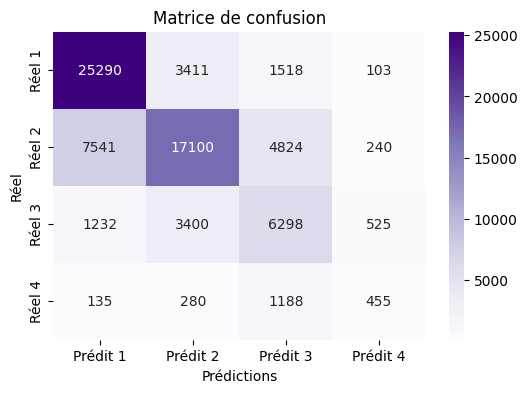

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# y_test = vraies classes
# y_pred = classes prédites

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Prédit 1', 'Prédit 2','Prédit 3', 'Prédit 4'],
            yticklabels=['Réel 1', 'Réel 2', 'Réel 3', 'Réel 4'])
plt.xlabel('Prédictions')
plt.ylabel('Réel')
plt.title('Matrice de confusion')
plt.show()


In [15]:
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

for i in indices[:20]:
    print(f"{X_encoded.columns[i]} : {importances[i]:.4f}")

age : 0.0699
secu1_Ceinture : 0.0464
vma : 0.0348
secu1_Casque : 0.0206
obs_Sans objet : 0.0204
secu1_Aucun équipement : 0.0203
agg_Hors agglomération : 0.0201
obsm_Aucun : 0.0184
catv_VL : 0.0179
catu_Piéton : 0.0166
obsm_Véhicule : 0.0140
sexe_Homme : 0.0139
catr_Route départementale : 0.0134
obsm_Piéton : 0.0122
choc_Avant : 0.0120
col_Deux véhicules - frontale : 0.0119
catu_Passager : 0.0118
catr_Voie communale : 0.0112
manv_Sans changement de direction : 0.0111
an_2024 : 0.0108


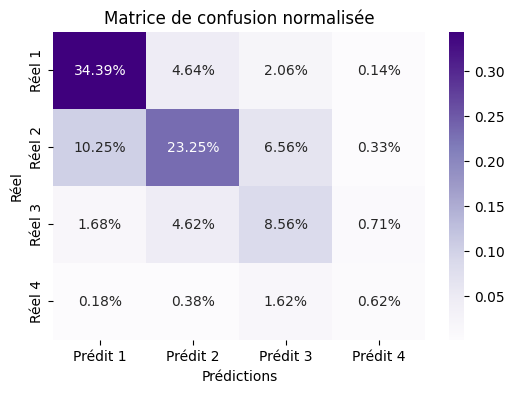

In [16]:
import numpy as np

cm = confusion_matrix(y_test, y_pred)
cm_norm = cm / np.sum(cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Purples',
            xticklabels=['Prédit 1', 'Prédit 2','Prédit 3', 'Prédit 4'],
            yticklabels=['Réel 1', 'Réel 2', 'Réel 3', 'Réel 4'])
plt.xlabel('Prédictions')
plt.ylabel('Réel')
plt.title('Matrice de confusion normalisée')
plt.show()


les classes 1 et 2 sont bien prédites, pour les classes 3 et 4 bcp moins debonnes prédictions, cela est du au fait que les données comporte moins d'accidnet comportant ces gravités de blessures, le 3 et 4 sont tué et blessures hospitalisé.
Sauf que nous on voudrait notamment prédire les tués pour voir ce qui est le plus dangereux ! Il va falloir donc rajouter des pénalisation :

In [17]:
from sklearn.ensemble import RandomForestClassifier

poids = {
    "1": 1,   # indemne
    "2": 1.07,   # blessé léger
    "3": 2.77,   # blessé hospitalisé
    "4": 15.4   # tué
}

rf2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight=poids,
    random_state=66,
    n_jobs=-1
)

rf2.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
y_pred2 = rf2.predict(X_test)

print(classification_report(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))



              precision    recall  f1-score   support

           1       0.74      0.83      0.78     30322
           2       0.70      0.58      0.64     29705
           3       0.45      0.55      0.50     11455
           4       0.35      0.22      0.27      2058

    accuracy                           0.67     73540
   macro avg       0.56      0.55      0.55     73540
weighted avg       0.67      0.67      0.67     73540

[[25091  3572  1562    97]
 [ 7339 17307  4827   232]
 [ 1191  3443  6299   522]
 [  127   285  1191   455]]


In [19]:
from imblearn.ensemble import BalancedRandomForestClassifier

brf = BalancedRandomForestClassifier(
    n_estimators=400,
    sampling_strategy="auto",
    random_state=66,
    n_jobs=-1
)

brf.fit(X_train, y_train)


,n_estimators,400
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [ ]:
y_pred_brf = brf.predict(X_test)

print(classification_report(y_test, y_pred_brf))
print(confusion_matrix(y_test, y_pred_brf))



### GridSearchCV


In [ ]:
param_grid = {
    "n_estimators": [100],   
    "max_depth": [None, 12, 20], 
    "class_weight": [
        {"1":1, "2":1, "3":2, "4":6},
        {"1":1, "2":1, "3":3, "4":15},
        "balanced_subsample"
    ]
}

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_grid = RandomForestClassifier(
    random_state=66,
    n_jobs=1
)

grid = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    scoring="recall_macro", # ou f1_weighted
    refit="recall_macro",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)


In [ ]:
print("Meilleurs paramètres :", grid.best_params_)
print("Meilleurs score :", grid.best_score_)


Selon la gridsearch les meilleurs parametres sont ci-dessus. Nous allons donc refaire un modele avce les paramètres.

In [ ]:
rf_opti = RandomForestClassifier(
    n_estimators=250,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=66,
    n_jobs=-1
)

rf_opti.fit(X_train, y_train)


In [ ]:
y_pred = rf_opti.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

on peut égalemtn tester avce plus d'arbres car avec la grid search trop d'arbre prennet trop de ressources donc compliqué par contre nous allons mettre un peu plus d'arbre car a chaque fois, les différentes gridsearch choisisse le plus grand nombre d'arbre disponible 

on remarque que les tué sont bien trouvé en revanche certains non tué sont predit en tué 

In [20]:
rf_opti2 = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=66,
    n_jobs=-1
)

rf_opti2.fit(X_train, y_train)

y_pred = rf_opti2.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.67      0.86      0.76     30322
           2       0.74      0.38      0.50     29705
           3       0.40      0.36      0.38     11455
           4       0.14      0.65      0.23      2058

    accuracy                           0.58     73540
   macro avg       0.49      0.56      0.47     73540
weighted avg       0.65      0.58      0.58     73540

[[26141  1609   973  1599]
 [10819 11267  4611  3008]
 [ 1684  2130  4074  3567]
 [  162   139   423  1334]]


In [22]:
from sklearn.metrics import balanced_accuracy_score
balanced_accuracy_score(y_test, y_pred)


0.5613161058191669

In [21]:
import pandas as pd
import numpy as np

importances = rf_opti2.feature_importances_
cols = X_train.columns

df_importances = pd.DataFrame({
    "variable": cols,
    "importance": importances
}).sort_values("importance", ascending=False)

df_importances.head(20)


,variable,importance
205,secu1_Ceinture,0.123431
204,secu1_Casque,0.051453
125,agg_Hors agglomération,0.046170
181,obsm_Aucun,0.045955
202,secu1_Aucun équipement,0.043870
176,obs_Sans objet,0.042541
1,age,0.042034
0,vma,0.039397
261,catu_Piéton,0.034949
160,catv_VL,0.032345


In [57]:
proba = rf_opti2.predict_proba(X_test)
proba_tue = proba[:, 3]   

df_corr = pd.DataFrame({
    "variable": X_test.columns,
    "corr": [np.corrcoef(X_test[col], proba_tue)[0,1] for col in X_test.columns]
})

df_corr["abs_corr"] = df_corr["corr"].abs()
df_corr.sort_values("abs_corr", ascending=False).head(20)


,variable,corr,abs_corr
181,obsm_Aucun,0.531479,0.531479
125,agg_Hors agglomération,0.483861,0.483861
176,obs_Sans objet,-0.472774,0.472774
196,situ_Sur accotement,0.443833,0.443833
184,obsm_Véhicule,-0.427954,0.427954
231,catr_Voie communale,-0.363336,0.363336
199,situ_Sur chaussée,-0.361521,0.361521
221,col_Deux véhicules - par le côté,-0.340953,0.340953
205,secu1_Ceinture,-0.335702,0.335702
229,catr_Route départementale,0.330212,0.330212


In [58]:
proba = rf_opti2.predict_proba(X_test)
proba_tue = proba[:, 0]   

df_corr = pd.DataFrame({
    "variable": X_test.columns,
    "corr": [np.corrcoef(X_test[col], proba_tue)[0,1] for col in X_test.columns]
})

df_corr["abs_corr"] = df_corr["corr"].abs()
df_corr.sort_values("abs_corr", ascending=False).head(20)

,variable,corr,abs_corr
205,secu1_Ceinture,0.696639,0.696639
204,secu1_Casque,-0.519586,0.519586
160,catv_VL,0.415651,0.415651
181,obsm_Aucun,-0.368506,0.368506
151,catv_Motocyclette,-0.362358,0.362358
202,secu1_Aucun équipement,-0.358899,0.358899
176,obs_Sans objet,0.322598,0.322598
261,catu_Piéton,-0.313259,0.313259
184,obsm_Véhicule,0.263204,0.263204
196,situ_Sur accotement,-0.244865,0.244865


In [59]:
proba = rf_opti2.predict_proba(X_test)
proba_tue = proba[:, 1]   

df_corr = pd.DataFrame({
    "variable": X_test.columns,
    "corr": [np.corrcoef(X_test[col], proba_tue)[0,1] for col in X_test.columns]
})

df_corr["abs_corr"] = df_corr["corr"].abs()
df_corr.sort_values("abs_corr", ascending=False).head(20)

,variable,corr,abs_corr
125,agg_Hors agglomération,-0.386381,0.386381
205,secu1_Ceinture,-0.380363,0.380363
231,catr_Voie communale,0.354922,0.354922
229,catr_Route départementale,-0.350199,0.350199
93,dep_75,0.322245,0.322245
204,secu1_Casque,0.301713,0.301713
196,situ_Sur accotement,-0.298976,0.298976
160,catv_VL,-0.296872,0.296872
154,catv_Scooter,0.294276,0.294276
184,obsm_Véhicule,0.255406,0.255406


In [60]:
proba = rf_opti2.predict_proba(X_test)
proba_tue = proba[:, 2]   

df_corr = pd.DataFrame({
    "variable": X_test.columns,
    "corr": [np.corrcoef(X_test[col], proba_tue)[0,1] for col in X_test.columns]
})

df_corr["abs_corr"] = df_corr["corr"].abs()
df_corr.sort_values("abs_corr", ascending=False).head(20)

,variable,corr,abs_corr
205,secu1_Ceinture,-0.667803,0.667803
204,secu1_Casque,0.596227,0.596227
160,catv_VL,-0.443237,0.443237
151,catv_Motocyclette,0.437931,0.437931
181,obsm_Aucun,0.337625,0.337625
202,secu1_Aucun équipement,0.295917,0.295917
184,obsm_Véhicule,-0.272331,0.272331
176,obs_Sans objet,-0.270069,0.270069
229,catr_Route départementale,0.260482,0.260482
261,catu_Piéton,0.259747,0.259747
